In [1]:
%pip install numpy
%pip install matplotlib
%pip install imageio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations
from helpers.env import SlipperyGridWorld, ACTIONS
from helpers.viz import evaluate, plot_policy, plot_value_heatmap, run_to_gif
from helpers.viz import greedy_policy_from_V
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)

(0, 1, 2, 3)


In [4]:
# =============================CONFIGURATION BLOCK============================= #
# |                   Change the parameters and see what happens              | #
# =============================CONFIGURATION BLOCK============================= #

# Example parameters set up for environment
num_rows = 5
num_cols = 7
start_state = (0, 0)
goal_state = (4, 6)
slip_prob = 0.2
random_seed = 987
step_reward = -1
goal_reward = 10

# VI parameters
max_number_iterations = 100 # max number of value iterations
threshold = 1e-5 # stopping condition
gamma = 0.99 # discount factor

# Evaluation parameters
max_steps_in_env = 20 # used for episodic evaluation


In [ ]:
# Note that states have both (row, column) and row*num_cols + column representations
# i.e., tuple(int, int) or int, see functions docstrings for details
env = SlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)
s = env.reset() # prepared clean environment

num_states = num_rows * num_cols # number of unique states
num_actions = env.nA

Q = np.random.default_rng(random_seed).uniform(low=-0.01, high=0.01, size=(num_states, num_actions))
for state in range(num_states):
    if env.is_terminal_state(state):
        Q[state] = 0.0

alpha = 0.2
epsilon = 1.0 # stala ilosc akcji wiec nie trzeba go zmiemniac
epsilon_min = 0.05
epsilon_decay = 0.995

rng = np.random.default_rng(random_seed)

for episode in range(max_number_iterations):
    X = env.reset(start_state)
    if rng.random() < epsilon:
        A = rng.integers(num_actions)
    else:
        A = int(np.argmax(Q[X]))


    while True:
      
        X_prim, R, done, info = env.step(A)

        if done:
            Q[X, A] += alpha * (R - Q[X, A])
            break

        # eps - greedy wybor
        if rng.random() < epsilon:
            A_prim = rng.integers(num_actions)
        else:
            A_prim = int(np.argmax(Q[X_prim]))
     

        Q[X, A] += alpha * (R + gamma * Q[X_prim, A_prim] - Q[X, A])

        X = X_prim
        A = A_prim

        
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

V = np.max(Q, axis=1)
pi = np.argmax(Q, axis=1)

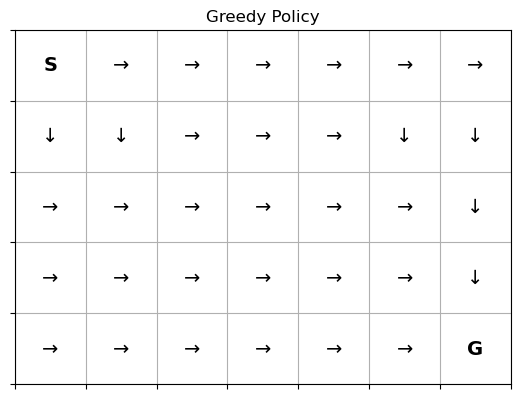

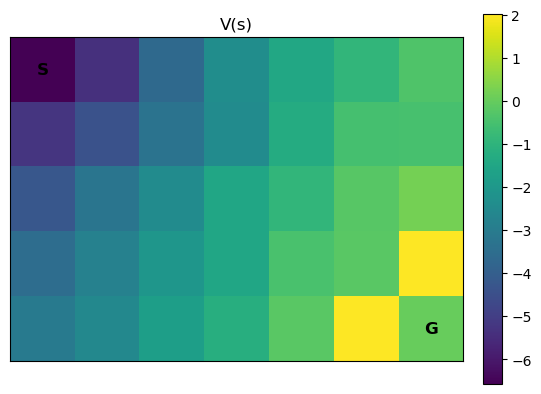

{'avg_return': -2.0, 'std_return': 3.6166, 'success_rate': 0.98, 'avg_steps': 12.78}


In [6]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

env.reset()

# retrieve policy from V(s)
pi = greedy_policy_from_V(V, env, gamma)

# visualize policy and V(s)
plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy")
plot_value_heatmap(env, V, filename=value_plot_name, title="V(s)")
plt.close("all")

# evaluate deterministic policy over multiple episodes 
metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

# save one episode to gif
run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)